<a href="https://colab.research.google.com/github/nithinbadicodes/AI-ML-Projects/blob/master/CollegeAdmissionsPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# College admissions prediction

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
df = pd.read_csv('admission_predict.csv')

In [26]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
70,71,332,118,5,5.0,5.0,9.64,1,0.94
123,124,308,108,3,3.5,3.5,8.22,0,0.61
473,474,316,102,2,4.0,3.5,8.15,0,0.67
468,469,323,110,4,4.0,5.0,8.88,1,0.81
229,230,324,111,4,3.0,3.0,9.01,1,0.82


In [27]:
# Renaming the columns with appropriate names
df = df.rename(columns={'GRE Score': 'GRE', 'TOEFL Score': 'TOEFL', 'LOR ': 'LOR', 'Chance of Admit ': 'Probability'})
df.head()

,Serial No.,GRE,TOEFL,University Rating,SOP,LOR,CGPA,Research,Probability
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [28]:
df.shape

(500, 9)

In [29]:
df.isnull().any()

,0
Serial No.,False
GRE,False
TOEFL,False
University Rating,False
SOP,False
LOR,False
CGPA,False
Research,False
Probability,False


In [30]:
df.columns

Index(['Serial No.', 'GRE', 'TOEFL', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Probability'],
      dtype='object')

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Serial No.,500.0,250.50000,144.481833,1.00,125.7500,250.50,375.25,500.00
GRE,500.0,316.47200,11.295148,290.00,308.0000,317.00,325.00,340.00
TOEFL,500.0,107.19200,6.081868,92.00,103.0000,107.00,112.00,120.00
University Rating,500.0,3.11400,1.143512,1.00,2.0000,3.00,4.00,5.00
SOP,500.0,3.37400,0.991004,1.00,2.5000,3.50,4.00,5.00
LOR,500.0,3.48400,0.925450,1.00,3.0000,3.50,4.00,5.00
CGPA,500.0,8.57644,0.604813,6.80,8.1275,8.56,9.04,9.92
Research,500.0,0.56000,0.496884,0.00,0.0000,1.00,1.00,1.00
Probability,500.0,0.72174,0.141140,0.34,0.6300,0.72,0.82,0.97


In [32]:
df.loc[:,df.columns[1:]]

,GRE,TOEFL,University Rating,SOP,LOR,CGPA,Research,Probability
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


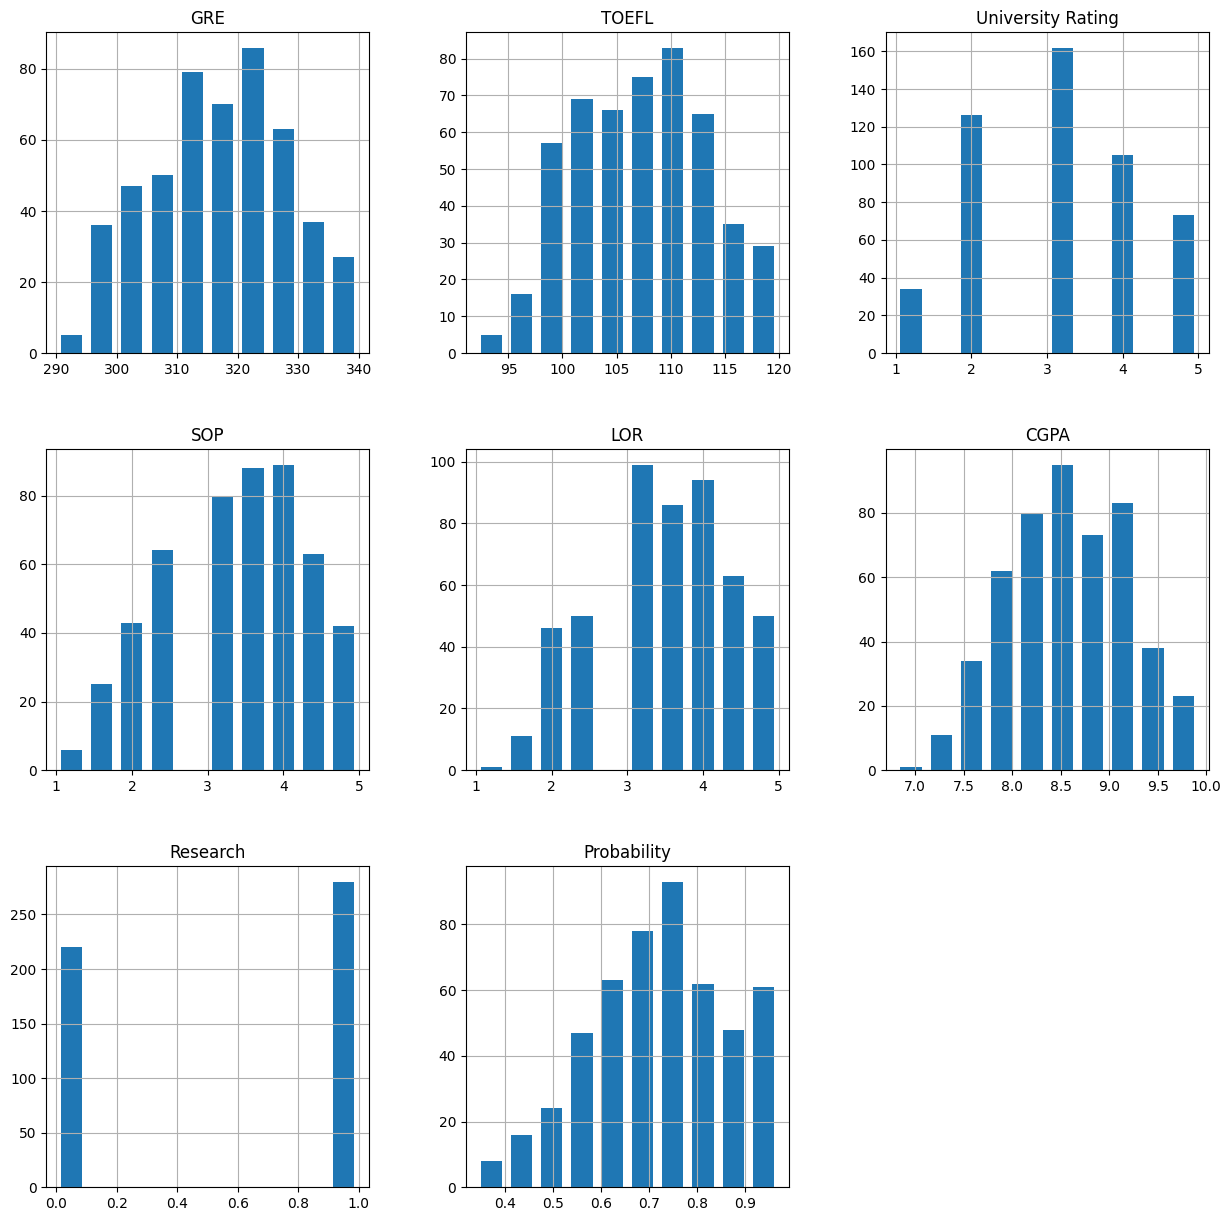

In [33]:
p = df.loc[:,df.columns[1:]].hist(figsize=(15,15),rwidth=0.7)

In [34]:
# Removing the serial no, column
df.drop('Serial No.', axis='columns', inplace=True)
df.head()

,GRE,TOEFL,University Rating,SOP,LOR,CGPA,Research,Probability
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## Model building

> First let's treat the probability has its own value and we will use Regression techniques.

In [40]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    'linear_regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'lasso': {
        'model': Lasso(),
        'params': {
            'alpha': [0.1, 1, 2],
            'selection': ['random', 'cyclic']
        }
    },
    'svr': {
        'model': SVR(),
        'params': {
            'gamma': ['auto', 'scale'],
            'C': [0.1, 1, 10]
        }
    },
    'decision_tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'criterion': ['squared_error', 'friedman_mse'],
            'splitter': ['best', 'random']
        }
    },
    'random_forest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [10, 20, 50],
            'max_depth': [None, 5, 10]
        }
    },
    'knn': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 10, 15]
        }
    }
}

In [42]:
from sklearn.model_selection import GridSearchCV
scores = []

for model_name,model_params in models.items():
  gs = GridSearchCV(model_params['model'],model_params['params'],cv=5,return_train_score=False)
  gs.fit(X,y)
  scores.append({
      'model':model_name,
      'best_parameters':gs.best_params_,
      'score':gs.best_score_
  })

scores_df = pd.DataFrame(scores,columns=['model','best_parameters','score'])
scores_df

,model,best_parameters,score
0,linear_regression,{},0.810802
1,lasso,"{'alpha': 0.1, 'selection': 'random'}",0.670176
2,svr,"{'C': 10, 'gamma': 'scale'}",0.703892
3,decision_tree,"{'criterion': 'friedman_mse', 'splitter': 'best'}",0.550900
4,random_forest,"{'max_depth': 5, 'n_estimators': 50}",0.787851
5,knn,{'n_neighbors': 15},0.717607


**Linear Regression is performing the best out of all of the above models**

In [44]:
# Splitting the dataset into train and test samples
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5)
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')

X_train shape: (400, 7), X_test shape: (100, 7)


In [45]:
# Creating Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.821478736588966